# 🌱 AgriSense — AI-Driven Vegetable Production & Price Optimization (Sri Lanka)

**Goal of this notebook**

For each of the three targets — **Price**, **Production Volume**, and **Weather (Rainfall forecast)** —
we train **3 candidate ML models**, compare their accuracy (RMSE / MAE / R²), automatically pick the
**best model per target**, and export everything (`.pkl` models + `.json` metadata + encoders) so the
AgriSense **mobile app backend** can load them directly and serve predictions. All EDA and evaluation
charts are saved as `.png` files for your documentation/report.

**Dataset:** `AgriSense_Dataset_2021_2025.xlsx` — 3 sheets:
1. `Weekly Prices` — Price ID, Date, Week No, Year, Season, Vegetable, District, Price (Rs/kg)
2. `Production Data` — Production ID, Vegetable, District, Year, Season, Cultivated Area (ha), Production Volume (Mt), Yield (Mt/ha)
3. `Weather Data` — Weather ID, Date (monthly), District, Temperature (°C), Rainfall (mm), Humidity (%)

> Run every cell top-to-bottom in Google Colab. All outputs (models, encoders, graphs, metrics) are saved
> into an `AgriSense_outputs/` folder and zipped at the end for easy download.


## 1. Setup — Install & Import Libraries

In [2]:
# Install extra ML libraries not pre-installed on some Colab runtimes
!pip install -q xgboost lightgbm joblib openpyxl

import os
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)

# Output folder — everything the mobile app / documentation needs goes here
OUT_DIR = "AgriSense_outputs"
GRAPH_DIR = os.path.join(OUT_DIR, "graphs")
MODEL_DIR = os.path.join(OUT_DIR, "models")
os.makedirs(GRAPH_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

RANDOM_STATE = 42
print("✅ Libraries loaded, output folders ready:", OUT_DIR)


✅ Libraries loaded, output folders ready: AgriSense_outputs


## 2. Upload & Load the Dataset

Run the cell below in Colab — it will pop up a file picker. Select `AgriSense_Dataset_2021_2025.xlsx`.
(If the file is already in your Colab working directory / mounted Drive, skip the upload widget and just
set `FILE_PATH` directly.)

In [3]:
FILE_PATH = "/content/AgriSense_Dataset_2021_2025.xlsx"

# --- Colab file upload (comment out if the file already exists at FILE_PATH) ---
try:
    from google.colab import files
    if not os.path.exists(FILE_PATH):
        print("Please select 'AgriSense_Dataset_2021_2025.xlsx' to upload:")
        uploaded = files.upload()
        FILE_PATH = list(uploaded.keys())[0]
except ImportError:
    pass  # not running in Colab

xls = pd.ExcelFile(FILE_PATH)
prices_df  = pd.read_excel(xls, sheet_name="Weekly Prices")
prod_df    = pd.read_excel(xls, sheet_name="Production Data")
weather_df = pd.read_excel(xls, sheet_name="Weather Data")

print("Weekly Prices  :", prices_df.shape)
print("Production Data:", prod_df.shape)
print("Weather Data   :", weather_df.shape)
prices_df.head()


Please select 'AgriSense_Dataset_2021_2025.xlsx' to upload:


Saving AgriSense_Dataset_2021_2025.xlsx.xlsx to AgriSense_Dataset_2021_2025.xlsx (1).xlsx
Weekly Prices  : (2300, 8)
Production Data: (100, 8)
Weather Data   : (120, 6)


,Price ID,Date,Week No,Year,Season,Vegetable,District,Price (Rs/kg)
0,1,2021-01-04,1,2021,Maha,Beans,Kandy,175.0
1,2,2021-01-04,1,2021,Maha,Cabbage,Kandy,65.0
2,3,2021-01-04,1,2021,Maha,Carrots,Kandy,125.0
3,4,2021-01-04,1,2021,Maha,Leeks,Kandy,75.0
4,5,2021-01-04,1,2021,Maha,Okra,Kandy,75.0


In [4]:
# Quick structural inspection
for name, df in [("Weekly Prices", prices_df), ("Production Data", prod_df), ("Weather Data", weather_df)]:
    print(f"\n===== {name} =====")
    print(df.dtypes)
    print("Missing values:\n", df.isna().sum())
    print("Duplicate rows:", df.duplicated().sum())



===== Weekly Prices =====
Price ID                  int64
Date             datetime64[ns]
Week No                   int64
Year                      int64
Season                   object
Vegetable                object
District                 object
Price (Rs/kg)           float64
dtype: object
Missing values:
 Price ID         0
Date             0
Week No          0
Year             0
Season           0
Vegetable        0
District         0
Price (Rs/kg)    0
dtype: int64
Duplicate rows: 0

===== Production Data =====
Production ID               int64
Vegetable                  object
District                   object
Year                        int64
Season                     object
Cultivated Area (ha)      float64
Production Volume (Mt)    float64
Yield (Mt/ha)             float64
dtype: object
Missing values:
 Production ID             0
Vegetable                 0
District                  0
Year                      0
Season                    0
Cultivated Area (ha)      0
Pro

## 3. Data Preprocessing & Merging

Steps:
1. Parse all `Date` columns to `datetime`.
2. Impute any missing numeric values with the column median (grouped by Vegetable/District where sensible)
   and fill missing categoricals with the mode — a safety net even if the raw file is already clean.
3. Weather is recorded **monthly** per district → extract `Year`/`Month` and merge to weekly prices by
   `(District, Year, Month)`. Also compute a **seasonal aggregate** (mean Temp/Rainfall/Humidity per
   District-Year-Season) to merge with the seasonal Production data.
4. Merge `Weekly Prices` + `Weather (monthly)` + `Production (seasonal)` into one master DataFrame.

In [5]:
# ---- 3.1 Parse dates ----
prices_df["Date"]  = pd.to_datetime(prices_df["Date"], dayfirst=True, errors="coerce")
weather_df["Date"] = pd.to_datetime(weather_df["Date"], dayfirst=True, errors="coerce")

prices_df["Month"]  = prices_df["Date"].dt.month
weather_df["Month"] = weather_df["Date"].dt.month
weather_df["Year"]  = weather_df["Date"].dt.year

# ---- 3.2 Missing value handling (safety net) ----
num_cols_prices  = ["Price (Rs/kg)"]
num_cols_prod    = ["Cultivated Area (ha)", "Production Volume (Mt)", "Yield (Mt/ha)"]
num_cols_weather = ["Temperature (°C)", "Rainfall (mm)", "Humidity (%)"]

for col in num_cols_prices:
    prices_df[col] = prices_df.groupby(["Vegetable", "District"])[col].transform(lambda s: s.fillna(s.median()))
for col in num_cols_prod:
    prod_df[col] = prod_df.groupby(["Vegetable", "District"])[col].transform(lambda s: s.fillna(s.median()))
for col in num_cols_weather:
    weather_df[col] = weather_df.groupby(["District"])[col].transform(lambda s: s.fillna(s.median()))

cat_cols = ["Season", "Vegetable", "District"]
for df_ in (prices_df, prod_df):
    for c in cat_cols:
        if c in df_.columns:
            df_[c] = df_[c].fillna(df_[c].mode()[0])

prices_df.dropna(subset=["Price (Rs/kg)"], inplace=True)

print("Remaining missing values (should all be 0):")
print(prices_df.isna().sum().sum(), prod_df.isna().sum().sum(), weather_df.isna().sum().sum())


Remaining missing values (should all be 0):
0 0 0


In [6]:
# ---- 3.3 Monthly weather -> merge onto weekly prices by (District, Year, Month) ----
weather_monthly = (weather_df.groupby(["District", "Year", "Month"])[num_cols_weather]
                              .mean().reset_index())

master_df = prices_df.merge(weather_monthly, on=["District", "Year", "Month"], how="left")

# ---- 3.4 Seasonal weather aggregate -> merge onto Production data ----
# Map month -> season is already given per record in prices/production; for weather we approximate
# Maha = Oct-Mar, Yala = Apr-Sep to build a matching seasonal weather aggregate for Production merging.
weather_monthly["Season"] = weather_monthly["Month"].apply(lambda m: "Maha" if m in [10,11,12,1,2,3] else "Yala")
weather_seasonal = (weather_monthly.groupby(["District", "Year", "Season"])[num_cols_weather]
                                    .mean().reset_index())

prod_merged = prod_df.merge(weather_seasonal, on=["District", "Year", "Season"], how="left")

# ---- 3.5 Attach production-side context (Cultivated Area, Yield, Production Volume) to the weekly price rows ----
master_df = master_df.merge(
    prod_df[["Vegetable", "District", "Year", "Season", "Cultivated Area (ha)",
             "Production Volume (Mt)", "Yield (Mt/ha)"]],
    on=["Vegetable", "District", "Year", "Season"], how="left"
)

# Fill any remaining gaps introduced by merges (e.g. edge months) with group medians
merge_fill_cols = num_cols_weather + ["Cultivated Area (ha)", "Production Volume (Mt)", "Yield (Mt/ha)"]
for col in merge_fill_cols:
    master_df[col] = master_df.groupby(["Vegetable", "District"])[col].transform(lambda s: s.fillna(s.median()))

master_df.sort_values(["Vegetable", "District", "Date"], inplace=True)
master_df.reset_index(drop=True, inplace=True)

master_df.to_csv(os.path.join(OUT_DIR, "AgriSense_master_dataset.csv"), index=False)
print("Master merged dataset shape:", master_df.shape)
master_df.head()


Master merged dataset shape: (2300, 15)


,Price ID,Date,Week No,Year,Season,Vegetable,District,Price (Rs/kg),Month,Temperature (°C),Rainfall (mm),Humidity (%),Cultivated Area (ha),Production Volume (Mt),Yield (Mt/ha)
0,1,2021-01-04,1,2021,Maha,Beans,Kandy,175.0,1,24.5,143.1,87.0,501.4,3073.7,6.130235
1,11,2021-01-07,1,2021,Maha,Beans,Kandy,165.0,1,24.5,143.1,87.0,501.4,3073.7,6.130235
2,21,2021-01-28,4,2021,Maha,Beans,Kandy,195.0,1,24.5,143.1,87.0,501.4,3073.7,6.130235
3,26,2021-02-12,6,2021,Maha,Beans,Kandy,210.0,2,25.0,54.6,80.5,501.4,3073.7,6.130235
4,36,2021-02-18,7,2021,Maha,Beans,Kandy,135.0,2,25.0,54.6,80.5,501.4,3073.7,6.130235


## 4. Exploratory Data Analysis (EDA)

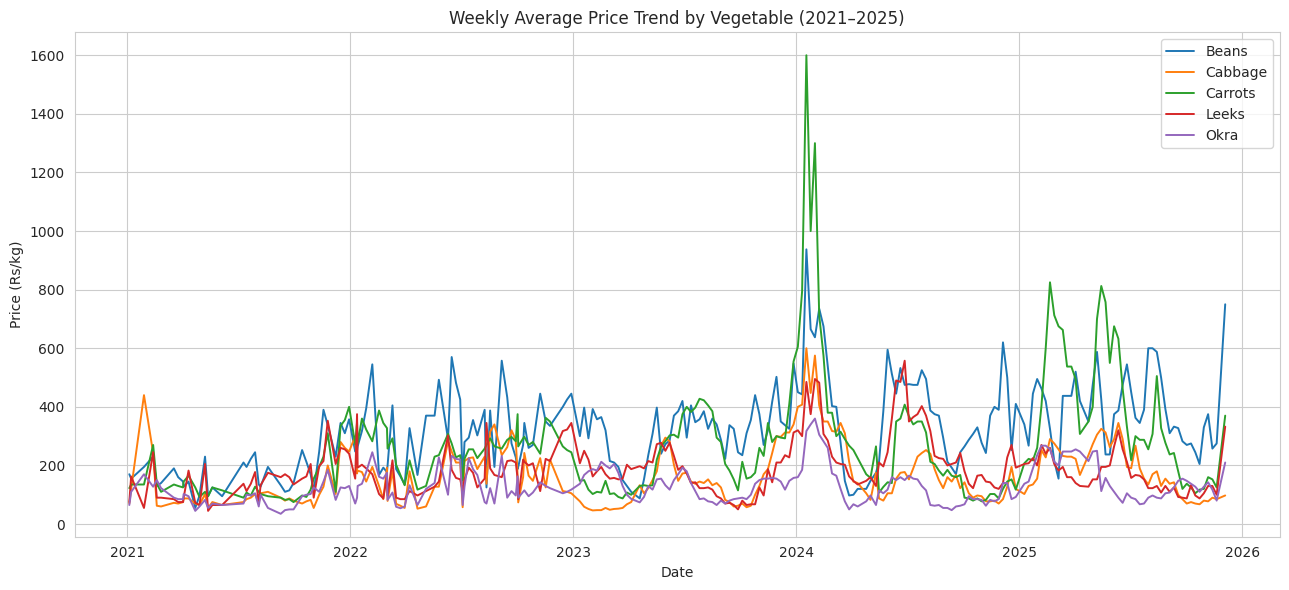

In [7]:
# ---- 4.1 Price trends per vegetable over time ----
fig, ax = plt.subplots(figsize=(13, 6))
for veg in master_df["Vegetable"].unique():
    veg_data = master_df[master_df["Vegetable"] == veg].groupby("Date")["Price (Rs/kg)"].mean()
    ax.plot(veg_data.index, veg_data.values, label=veg, linewidth=1.4)
ax.set_title("Weekly Average Price Trend by Vegetable (2021–2025)")
ax.set_xlabel("Date"); ax.set_ylabel("Price (Rs/kg)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "01_price_trends.png"), dpi=150)
plt.show()


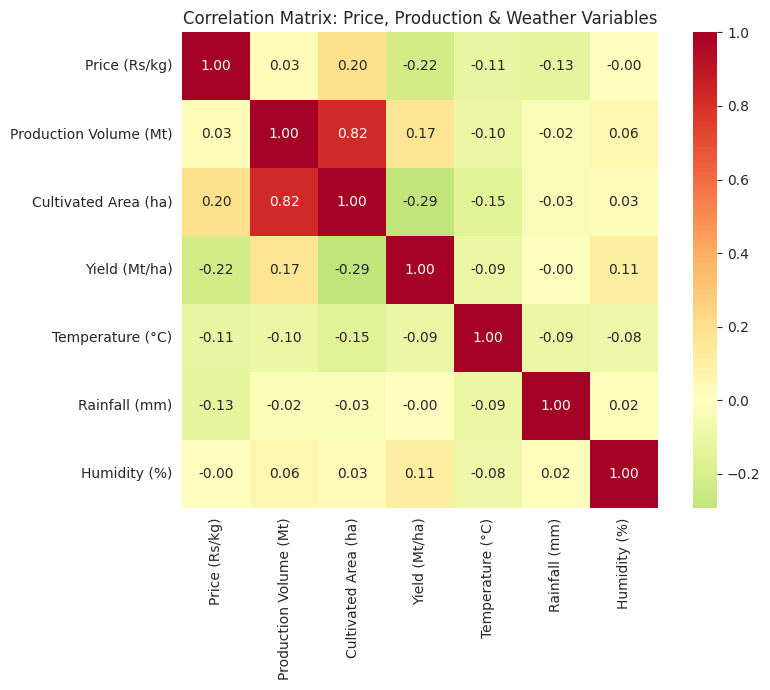

In [8]:
# ---- 4.2 Correlation matrix ----
corr_cols = ["Price (Rs/kg)", "Production Volume (Mt)", "Cultivated Area (ha)", "Yield (Mt/ha)",
             "Temperature (°C)", "Rainfall (mm)", "Humidity (%)"]
corr = master_df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn_r", center=0, square=True)
plt.title("Correlation Matrix: Price, Production & Weather Variables")
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "02_correlation_matrix.png"), dpi=150)
plt.show()


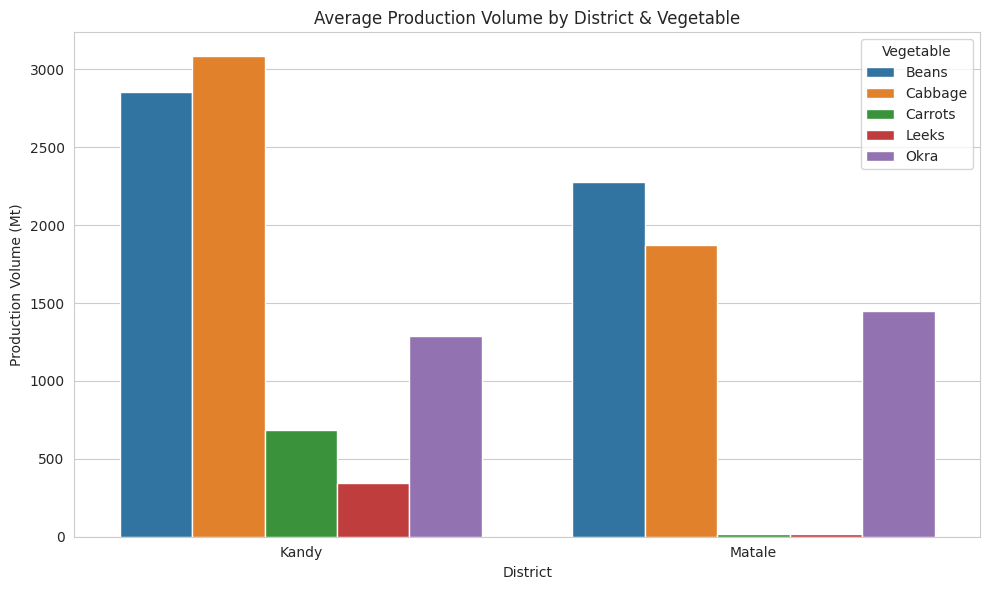

In [9]:
# ---- 4.3 Production volume across districts ----
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=prod_df, x="District", y="Production Volume (Mt)", hue="Vegetable",
            estimator=np.mean, errorbar=None, ax=ax)
ax.set_title("Average Production Volume by District & Vegetable")
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "03_production_by_district.png"), dpi=150)
plt.show()


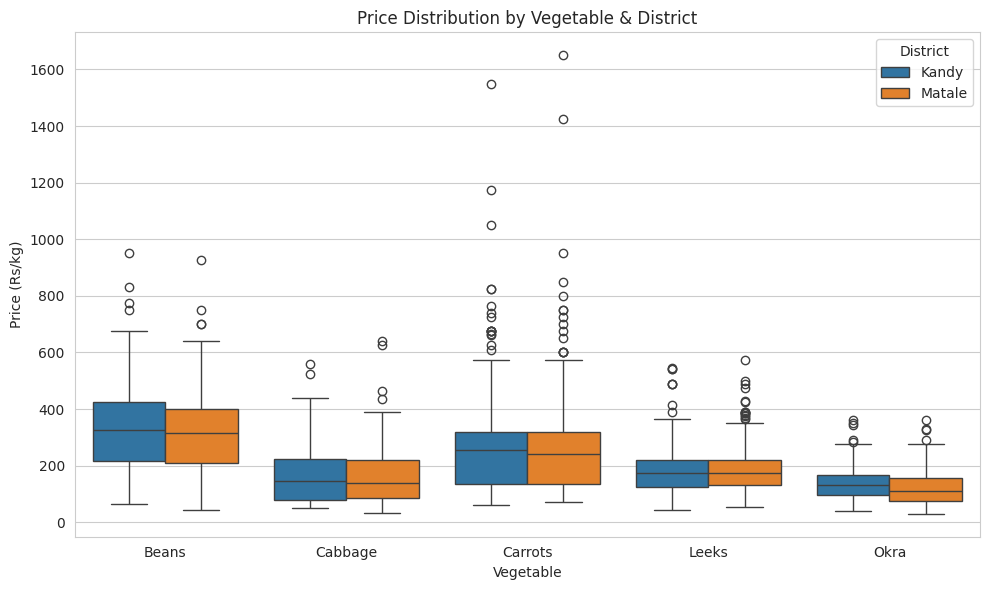

In [10]:
# ---- 4.4 Price distribution per vegetable (boxplot) ----
plt.figure(figsize=(10, 6))
sns.boxplot(data=master_df, x="Vegetable", y="Price (Rs/kg)", hue="District")
plt.title("Price Distribution by Vegetable & District")
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "04_price_distribution.png"), dpi=150)
plt.show()


## 5. Feature Engineering

- Extract `Month` / `Year` (already have `Month`; `Year` present).
- Label-encode `Season`, `Vegetable`, `District` (tree-based models handle label encoding fine, and it
  keeps the feature set compact for mobile-side inference).
- Create **lag features** for price (previous 1/2/3 observations of that Vegetable+District) and for
  production (previous season's volume), which materially improve time-series accuracy.

In [11]:
master_df = master_df.sort_values(["Vegetable", "District", "Date"]).reset_index(drop=True)

# ---- Label Encoding (store encoders for the mobile-app backend) ----
encoders = {}
for col in ["Season", "Vegetable", "District"]:
    le = LabelEncoder()
    master_df[col + "_enc"] = le.fit_transform(master_df[col])
    encoders[col] = {cls: int(idx) for idx, cls in enumerate(le.classes_)}

# ---- Lag features for price ----
grp = master_df.groupby(["Vegetable", "District"])["Price (Rs/kg)"]
master_df["Price_lag_1"] = grp.shift(1)
master_df["Price_lag_2"] = grp.shift(2)
master_df["Price_lag_3"] = grp.shift(3)
master_df["Price_rolling_mean_3"] = grp.transform(lambda s: s.shift(1).rolling(3).mean())

# Fill lag NaNs (first rows of each group) with that group's median price
for col in ["Price_lag_1", "Price_lag_2", "Price_lag_3", "Price_rolling_mean_3"]:
    master_df[col] = master_df.groupby(["Vegetable", "District"])[col] \
                               .transform(lambda s: s.fillna(s.median()))

# ---- Lag feature for production (previous season's volume, per Vegetable+District) ----
prod_merged = prod_merged.sort_values(["Vegetable", "District", "Year", "Season"]).reset_index(drop=True)
prod_merged["Production_lag_1"] = prod_merged.groupby(["Vegetable", "District"])["Production Volume (Mt)"].shift(1)
prod_merged["Production_lag_1"] = prod_merged.groupby(["Vegetable", "District"])["Production_lag_1"] \
                                               .transform(lambda s: s.fillna(s.median()))

for col in ["Season", "Vegetable", "District"]:
    prod_merged[col + "_enc"] = prod_merged[col].map(encoders[col])

print("Feature engineering complete.")
master_df[["Vegetable", "District", "Date", "Price (Rs/kg)", "Price_lag_1", "Price_lag_2",
           "Price_rolling_mean_3"]].head(8)


Feature engineering complete.


,Vegetable,District,Date,Price (Rs/kg),Price_lag_1,Price_lag_2,Price_rolling_mean_3
0,Beans,Kandy,2021-01-04,175.0,325.0,325.0,320.833333
1,Beans,Kandy,2021-01-07,165.0,175.0,325.0,320.833333
2,Beans,Kandy,2021-01-28,195.0,165.0,175.0,320.833333
3,Beans,Kandy,2021-02-12,210.0,195.0,165.0,178.333333
4,Beans,Kandy,2021-02-18,135.0,210.0,195.0,190.000000
5,Beans,Kandy,2021-02-25,125.0,135.0,210.0,180.000000
6,Beans,Kandy,2021-03-18,190.0,125.0,135.0,156.666667
7,Beans,Kandy,2021-03-25,175.0,190.0,125.0,150.000000


## 6. Train / Test Split

Per the project brief: **train on 2021–2024, test on 2025** — this simulates real forecasting
(predicting a future, unseen year), which is what the mobile app will actually need to do.

In [12]:
PRICE_FEATURES = ["Week No", "Month", "Year", "Season_enc", "Vegetable_enc", "District_enc",
                   "Temperature (°C)", "Rainfall (mm)", "Humidity (%)",
                   "Cultivated Area (ha)", "Yield (Mt/ha)",
                   "Price_lag_1", "Price_lag_2", "Price_lag_3", "Price_rolling_mean_3"]
PRICE_TARGET = "Price (Rs/kg)"

train_price = master_df[master_df["Year"] <= 2024]
test_price  = master_df[master_df["Year"] == 2025]

X_train_p, y_train_p = train_price[PRICE_FEATURES], train_price[PRICE_TARGET]
X_test_p,  y_test_p  = test_price[PRICE_FEATURES],  test_price[PRICE_TARGET]

print("Price model -> train:", X_train_p.shape, " test:", X_test_p.shape)

PROD_FEATURES = ["Year", "Season_enc", "Vegetable_enc", "District_enc",
                  "Cultivated Area (ha)", "Temperature (°C)", "Rainfall (mm)", "Humidity (%)",
                  "Production_lag_1"]
PROD_TARGET = "Production Volume (Mt)"

train_prod = prod_merged[prod_merged["Year"] <= 2024]
test_prod  = prod_merged[prod_merged["Year"] == 2025]

X_train_pr, y_train_pr = train_prod[PROD_FEATURES], train_prod[PROD_TARGET]
X_test_pr,  y_test_pr  = test_prod[PROD_FEATURES],  test_prod[PROD_TARGET]

print("Production model -> train:", X_train_pr.shape, " test:", X_test_pr.shape)


Price model -> train: (1850, 15)  test: (450, 15)
Production model -> train: (80, 9)  test: (20, 9)


## 7. Model Training — 3 Candidates per Target, Best-Model Auto-Selection

For **each** target (Price, Production, and a bonus Weather/Rainfall forecast) we train:
1. **Random Forest Regressor**
2. **Gradient Boosting Regressor**
3. **XGBoost Regressor**

...evaluate all three on the held-out 2025 test set (RMSE, MAE, R²), and automatically keep the
best one (lowest RMSE) as `best_<target>_model`.

In [13]:
def get_candidate_models():
    """Fresh set of 3 candidate regressors (call once per target to avoid state leakage)."""
    return {
        "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=None,
                                               random_state=RANDOM_STATE, n_jobs=-1),
        "GradientBoosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                       max_depth=3, random_state=RANDOM_STATE),
        "XGBoost": XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=4,
                                 subsample=0.9, colsample_bytree=0.9,
                                 random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    }

def train_and_compare(X_train, y_train, X_test, y_test, target_name):
    """Train all 3 candidates, evaluate, return (results_df, fitted_models_dict, best_model_name)."""
    models = get_candidate_models()
    results = []
    fitted = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae  = mean_absolute_error(y_test, preds)
        r2   = r2_score(y_test, preds)
        results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})
        fitted[name] = model
        print(f"[{target_name}] {name:<18} RMSE={rmse:8.3f}  MAE={mae:8.3f}  R2={r2:6.3f}")

    results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
    best_name = results_df.iloc[0]["Model"]
    print(f"\n🏆 Best model for {target_name}: {best_name}\n")
    return results_df, fitted, best_name

def plot_model_comparison(results_df, target_name, filename):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
        sns.barplot(data=results_df, x="Model", y=metric, ax=ax, palette="viridis")
        ax.set_title(f"{target_name} — {metric}")
        ax.tick_params(axis='x', rotation=15)
    plt.tight_layout()
    plt.savefig(os.path.join(GRAPH_DIR, filename), dpi=150)
    plt.show()


[Price] RandomForest       RMSE=  87.625  MAE=  56.392  R2= 0.700
[Price] GradientBoosting   RMSE=  95.842  MAE=  62.158  R2= 0.641
[Price] XGBoost            RMSE=  99.051  MAE=  64.207  R2= 0.617

🏆 Best model for Price: RandomForest



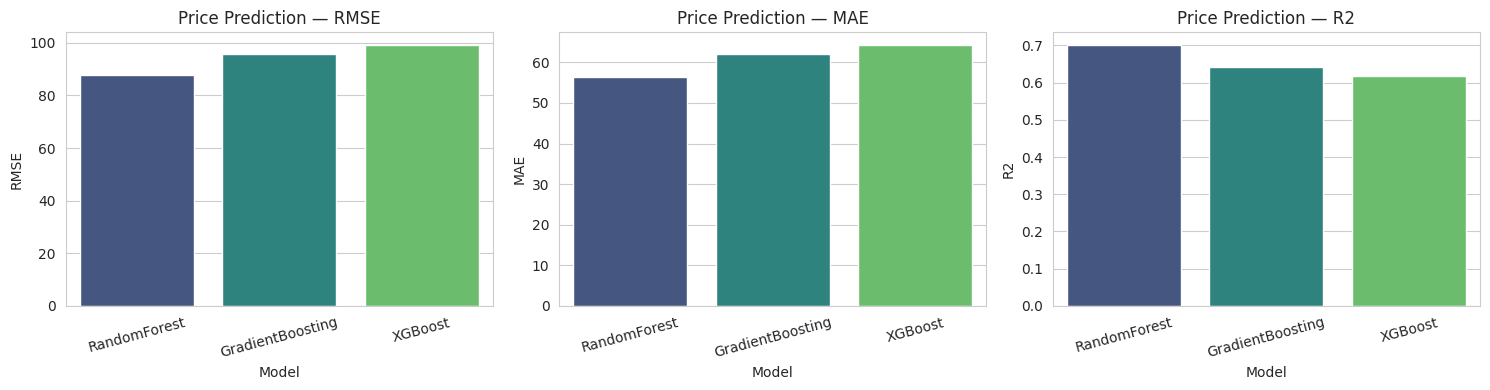

,Model,RMSE,MAE,R2
0,RandomForest,87.625075,56.391711,0.700299
1,GradientBoosting,95.841837,62.158070,0.641457
2,XGBoost,99.050804,64.206503,0.617046


In [14]:
# ---- 7.1 PRICE model ----
price_results_df, price_models, best_price_name = train_and_compare(
    X_train_p, y_train_p, X_test_p, y_test_p, "Price")
plot_model_comparison(price_results_df, "Price Prediction", "05_price_model_comparison.png")
price_results_df


[Production] RandomForest       RMSE= 240.922  MAE= 167.626  R2= 0.936
[Production] GradientBoosting   RMSE= 198.781  MAE= 137.144  R2= 0.956
[Production] XGBoost            RMSE= 207.513  MAE= 145.797  R2= 0.952

🏆 Best model for Production: GradientBoosting



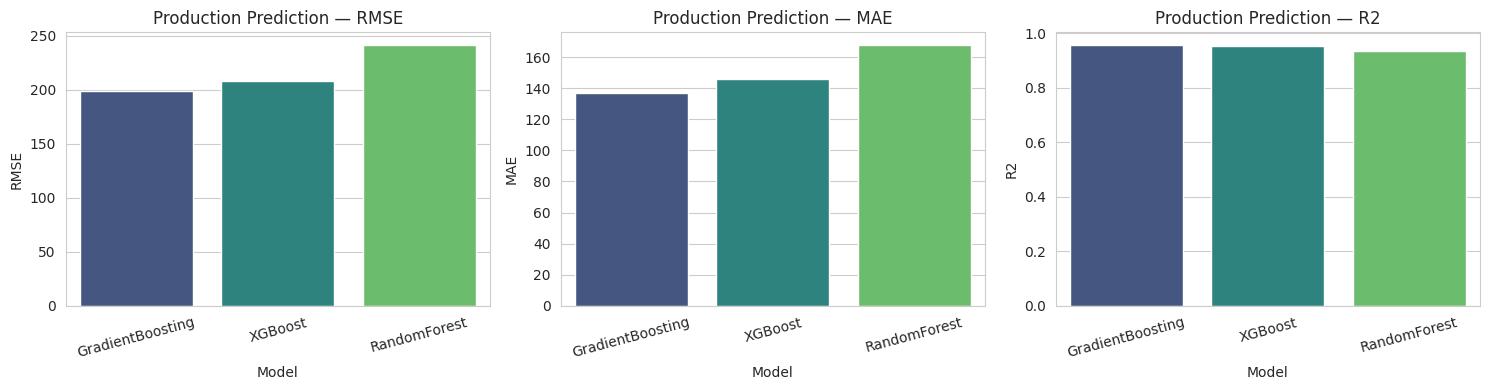

,Model,RMSE,MAE,R2
0,GradientBoosting,198.780628,137.144224,0.956282
1,XGBoost,207.512723,145.797048,0.952357
2,RandomForest,240.922390,167.626217,0.935781


In [15]:
# ---- 7.2 PRODUCTION model ----
prod_results_df, prod_models, best_prod_name = train_and_compare(
    X_train_pr, y_train_pr, X_test_pr, y_test_pr, "Production")
plot_model_comparison(prod_results_df, "Production Prediction", "06_production_model_comparison.png")
prod_results_df


[Rainfall] RandomForest       RMSE= 130.799  MAE=  86.854  R2= 0.398
[Rainfall] GradientBoosting   RMSE= 109.840  MAE=  72.380  R2= 0.575
[Rainfall] XGBoost            RMSE= 110.741  MAE=  76.588  R2= 0.568

🏆 Best model for Rainfall: GradientBoosting



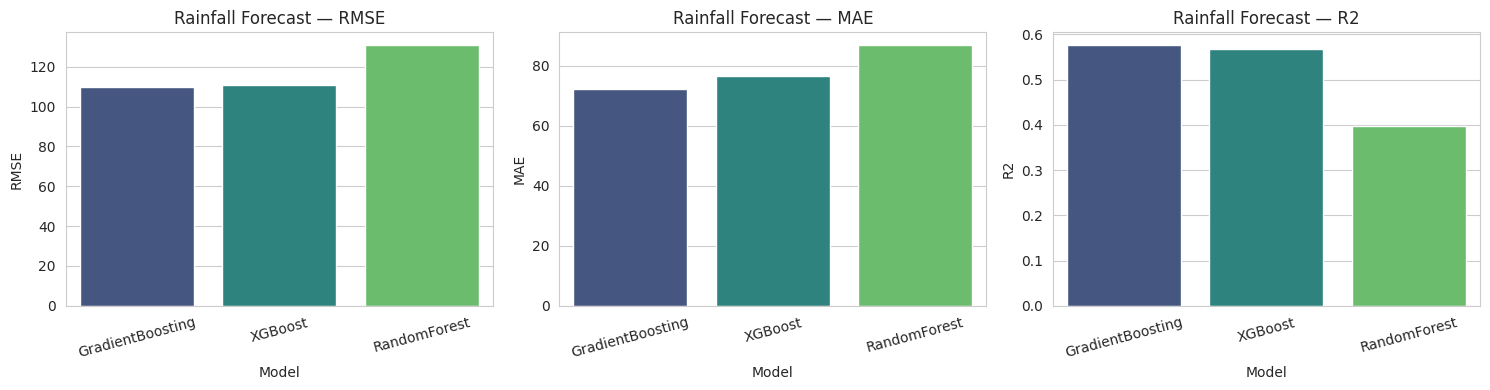

,Model,RMSE,MAE,R2
0,GradientBoosting,109.840004,72.379989,0.575480
1,XGBoost,110.740606,76.588138,0.568490
2,RandomForest,130.799353,86.854021,0.398011


In [16]:
# ---- 7.3 WEATHER (Rainfall) forecast model — bonus, as requested ----
# Predict next-month rainfall per district from month/season/temperature/humidity/lags.
weather_feat_df = weather_monthly.sort_values(["District", "Year", "Month"]).reset_index(drop=True)
weather_feat_df["District_enc"] = weather_feat_df["District"].map(encoders["District"])
weather_feat_df["Rainfall_lag_1"] = weather_feat_df.groupby("District")["Rainfall (mm)"].shift(1)
weather_feat_df["Rainfall_lag_1"] = weather_feat_df.groupby("District")["Rainfall_lag_1"] \
                                                     .transform(lambda s: s.fillna(s.median()))

WEATHER_FEATURES = ["Month", "Year", "District_enc", "Temperature (°C)", "Humidity (%)", "Rainfall_lag_1"]
WEATHER_TARGET = "Rainfall (mm)"

train_w = weather_feat_df[weather_feat_df["Year"] <= 2024]
test_w  = weather_feat_df[weather_feat_df["Year"] == 2025]

X_train_w, y_train_w = train_w[WEATHER_FEATURES], train_w[WEATHER_TARGET]
X_test_w,  y_test_w  = test_w[WEATHER_FEATURES],  test_w[WEATHER_TARGET]

weather_results_df, weather_models, best_weather_name = train_and_compare(
    X_train_w, y_train_w, X_test_w, y_test_w, "Rainfall")
plot_model_comparison(weather_results_df, "Rainfall Forecast", "07_weather_model_comparison.png")
weather_results_df


## 8. Feature Importance — Best Model per Target

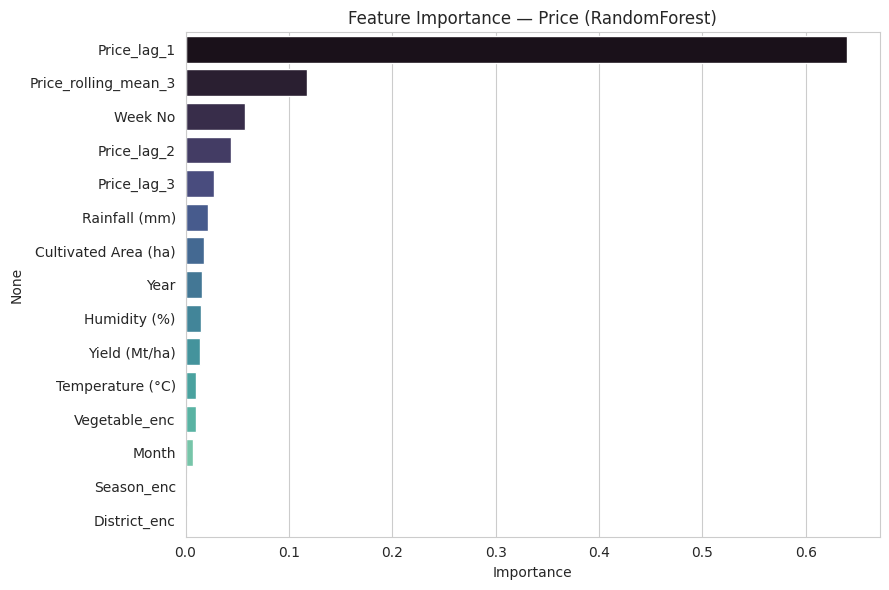

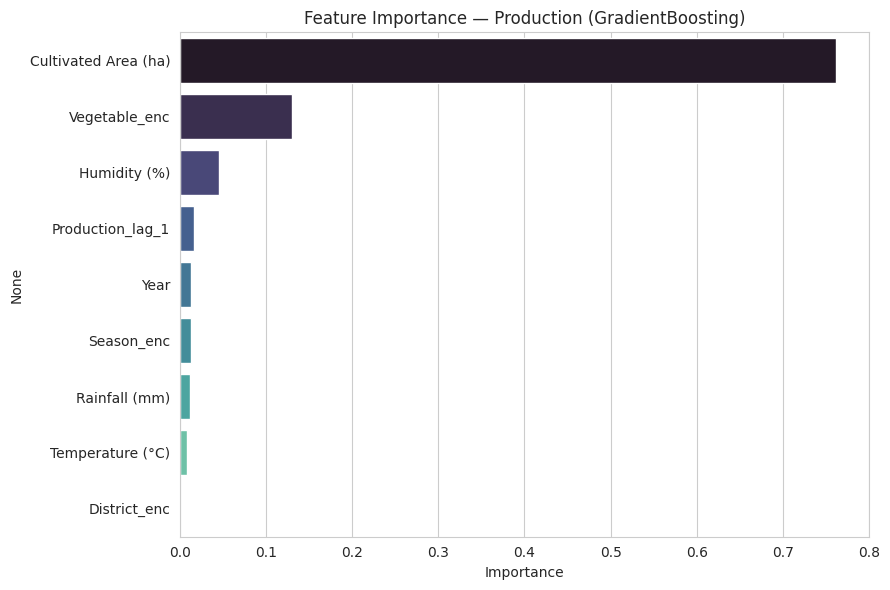

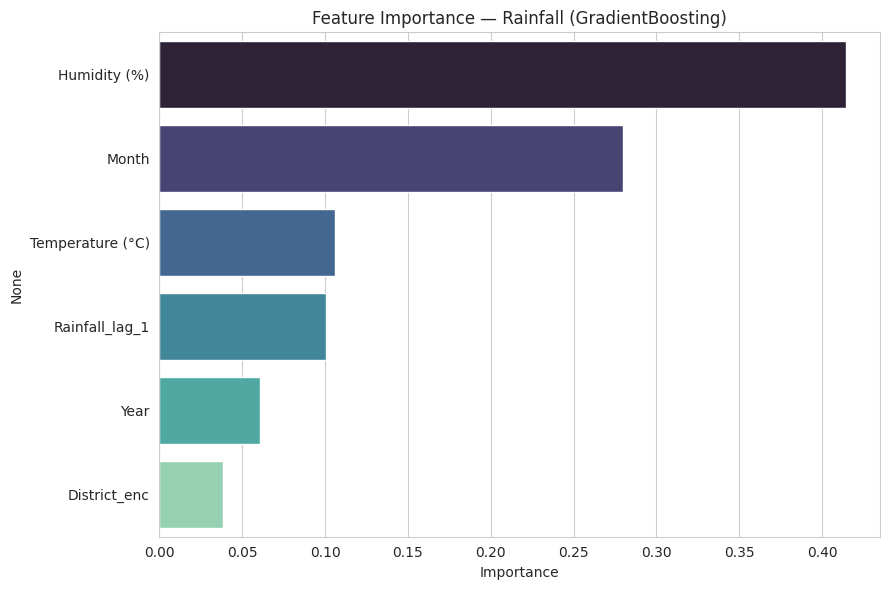

In [17]:
def plot_feature_importance(model, feature_names, title, filename):
    if not hasattr(model, "feature_importances_"):
        print(f"{title}: model has no feature_importances_ attribute, skipping.")
        return
    importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    plt.figure(figsize=(9, 6))
    sns.barplot(x=importances.values, y=importances.index, palette="mako")
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig(os.path.join(GRAPH_DIR, filename), dpi=150)
    plt.show()
    return importances

best_price_model    = price_models[best_price_name]
best_prod_model      = prod_models[best_prod_name]
best_weather_model   = weather_models[best_weather_name]

price_importance = plot_feature_importance(
    best_price_model, PRICE_FEATURES, f"Feature Importance — Price ({best_price_name})",
    "08_price_feature_importance.png")

prod_importance = plot_feature_importance(
    best_prod_model, PROD_FEATURES, f"Feature Importance — Production ({best_prod_name})",
    "09_production_feature_importance.png")

weather_importance = plot_feature_importance(
    best_weather_model, WEATHER_FEATURES, f"Feature Importance — Rainfall ({best_weather_name})",
    "10_weather_feature_importance.png")


## 9. Export Everything for the Mobile App Backend

Saved into `AgriSense_outputs/`:
- `models/best_price_model.pkl`, `models/best_production_model.pkl`, `models/best_weather_model.pkl`
- `encoders.json` — label-encoding maps for `Season`, `Vegetable`, `District` (needed to turn app inputs
  like `"Vegetable": "Carrots"` into the numeric codes the models expect)
- `model_metadata.json` — feature order, target name, and chosen best model per task, so the backend
  knows exactly what to send the model and in what order
- `model_performance_summary.csv` — RMSE/MAE/R² for all 9 trained candidates, for your documentation
- `graphs/*.png` — every chart generated above, ready to drop into a report/presentation

In [18]:
# ---- Save models ----
joblib.dump(best_price_model,   os.path.join(MODEL_DIR, "best_price_model.pkl"))
joblib.dump(best_prod_model,    os.path.join(MODEL_DIR, "best_production_model.pkl"))
joblib.dump(best_weather_model, os.path.join(MODEL_DIR, "best_weather_model.pkl"))

# ---- Save encoders ----
with open(os.path.join(OUT_DIR, "encoders.json"), "w") as f:
    json.dump(encoders, f, indent=2)

# ---- Save metadata the backend needs to call the models correctly ----
metadata = {
    "price_model": {
        "file": "models/best_price_model.pkl",
        "algorithm": best_price_name,
        "features_in_order": PRICE_FEATURES,
        "target": PRICE_TARGET,
    },
    "production_model": {
        "file": "models/best_production_model.pkl",
        "algorithm": best_prod_name,
        "features_in_order": PROD_FEATURES,
        "target": PROD_TARGET,
    },
    "weather_model": {
        "file": "models/best_weather_model.pkl",
        "algorithm": best_weather_name,
        "features_in_order": WEATHER_FEATURES,
        "target": WEATHER_TARGET,
    },
    "categorical_encoders": "encoders.json",
    "notes": "Categorical inputs (Season, Vegetable, District) must be converted to their integer code "
             "via encoders.json BEFORE being passed to the models, in the exact feature order listed above."
}
with open(os.path.join(OUT_DIR, "model_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

# ---- Save full metrics table for documentation ----
price_results_df["Target"] = "Price"
prod_results_df["Target"] = "Production"
weather_results_df["Target"] = "Rainfall"
all_results = pd.concat([price_results_df, prod_results_df, weather_results_df], ignore_index=True)
all_results.to_csv(os.path.join(OUT_DIR, "model_performance_summary.csv"), index=False)

print("✅ Saved models, encoders, metadata and metrics summary.")
all_results


✅ Saved models, encoders, metadata and metrics summary.


,Model,RMSE,MAE,R2,Target
0,RandomForest,87.625075,56.391711,0.700299,Price
1,GradientBoosting,95.841837,62.158070,0.641457,Price
2,XGBoost,99.050804,64.206503,0.617046,Price
3,GradientBoosting,198.780628,137.144224,0.956282,Production
4,XGBoost,207.512723,145.797048,0.952357,Production
5,RandomForest,240.922390,167.626217,0.935781,Production
6,GradientBoosting,109.840004,72.379989,0.575480,Rainfall
7,XGBoost,110.740606,76.588138,0.568490,Rainfall
8,RandomForest,130.799353,86.854021,0.398011,Rainfall


In [19]:
# ---- Example inference function (mirrors what the mobile backend should do) ----
def predict_price(vegetable, district, season, week_no, month, year,
                   temperature, rainfall, humidity, cultivated_area, yield_mt_ha,
                   price_lag_1, price_lag_2, price_lag_3, price_rolling_mean_3):
    model = joblib.load(os.path.join(MODEL_DIR, "best_price_model.pkl"))
    with open(os.path.join(OUT_DIR, "encoders.json")) as f:
        enc = json.load(f)
    row = pd.DataFrame([{
        "Week No": week_no, "Month": month, "Year": year,
        "Season_enc": enc["Season"][season],
        "Vegetable_enc": enc["Vegetable"][vegetable],
        "District_enc": enc["District"][district],
        "Temperature (°C)": temperature, "Rainfall (mm)": rainfall, "Humidity (%)": humidity,
        "Cultivated Area (ha)": cultivated_area, "Yield (Mt/ha)": yield_mt_ha,
        "Price_lag_1": price_lag_1, "Price_lag_2": price_lag_2, "Price_lag_3": price_lag_3,
        "Price_rolling_mean_3": price_rolling_mean_3,
    }])[PRICE_FEATURES]
    return float(model.predict(row)[0])

# Demo call using the last known values for Carrots in Kandy
sample = master_df[(master_df.Vegetable == "Carrots") & (master_df.District == "Kandy")].iloc[-1]
demo_price = predict_price(
    vegetable="Carrots", district="Kandy", season=sample["Season"],
    week_no=int(sample["Week No"]), month=int(sample["Month"]), year=2025,
    temperature=sample["Temperature (°C)"], rainfall=sample["Rainfall (mm)"], humidity=sample["Humidity (%)"],
    cultivated_area=sample["Cultivated Area (ha)"], yield_mt_ha=sample["Yield (Mt/ha)"],
    price_lag_1=sample["Price (Rs/kg)"], price_lag_2=sample["Price_lag_1"],
    price_lag_3=sample["Price_lag_2"], price_rolling_mean_3=sample["Price_rolling_mean_3"]
)
print(f"Demo predicted price for Carrots (Kandy): Rs. {demo_price:.2f} / kg")


Demo predicted price for Carrots (Kandy): Rs. 275.53 / kg


## 10. Zip Everything for Download

Downloads `AgriSense_outputs.zip` containing: trained models, encoders, metadata, metrics CSV, and all
documentation-ready graphs.

In [20]:
import shutil
zip_path = shutil.make_archive("AgriSense_outputs", "zip", OUT_DIR)
print("Created:", zip_path)

try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print(f"Not running in Colab — find the zip at: {os.path.abspath(zip_path)}")


Created: /content/AgriSense_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary

| Target | Candidates Tried | Best Model | Where it's used in the app |
|---|---|---|---|
| **Price (Rs/kg)** | Random Forest, Gradient Boosting, XGBoost | *(printed above as `best_price_name`)* | Predicts next-week vegetable price per district |
| **Production Volume (Mt)** | Random Forest, Gradient Boosting, XGBoost | *(printed above as `best_prod_name`)* | Predicts upcoming season's yield/volume |
| **Rainfall (mm)** | Random Forest, Gradient Boosting, XGBoost | *(printed above as `best_weather_name`)* | Feeds forecasted weather into the price/production models |

All three best models, their encoders, and a `model_metadata.json` describing the exact feature order are
packaged in `AgriSense_outputs.zip` — hand this to whoever builds the mobile app's backend/API and they can
load each `.pkl` with `joblib.load(...)` and call `.predict()` directly.
